In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scanpy as scp
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid.inset_locator import inset_axes
import matplotlib.patches as mpatches
import igraph
import scipy.stats as st
import bbknn

from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier

# Whole

In [2]:
adata_embryo = scp.read("results/embryo/Embryo_corrected.h5ad")
adata_gastruloid = scp.read("results/QC.h5ad")

In [3]:
common_genes_embryo = [i in adata_gastruloid.var.index.values for i in adata_embryo.var.index.values]
common_genes_gastruloids = [i in adata_embryo.var.index.values for i in adata_gastruloid.var.index.values]

In [4]:
#Get to the common number of genes
adata_embryo = adata_embryo[:,common_genes_embryo]
adata_gastruloid = adata_gastruloid[:,common_genes_gastruloids]

## PCA embryo

In [5]:
scp.pp.highly_variable_genes(adata_embryo,flavor="seurat")
X = adata_embryo.X[:,adata_embryo.var.loc[:,"highly_variable"]]

Trying to set attribute `.uns` of view, copying.


In [6]:
m = TruncatedSVD(12)
m.fit(X)
X_pca_embryo = m.transform(X)

## Project gastruloids over PCA of the embryo

In [7]:
X = adata_gastruloid.X[:,adata_embryo.var.loc[:,"highly_variable"]]

In [8]:
X_pca_gastruloid = m.transform(X)

## Project over the UMAP

In [9]:
adata_embryo.obsm

AxisArrays with keys: X_umap_original

In [10]:
UMAP_embryo = adata_embryo.obsm["X_umap_original"]

m = KNeighborsRegressor(3,metric="correlation")
m.fit(X_pca_embryo,UMAP_embryo)

KNeighborsRegressor(metric='correlation', n_neighbors=3)

In [11]:
UMAP_gastruloid = m.predict(X_pca_gastruloid)

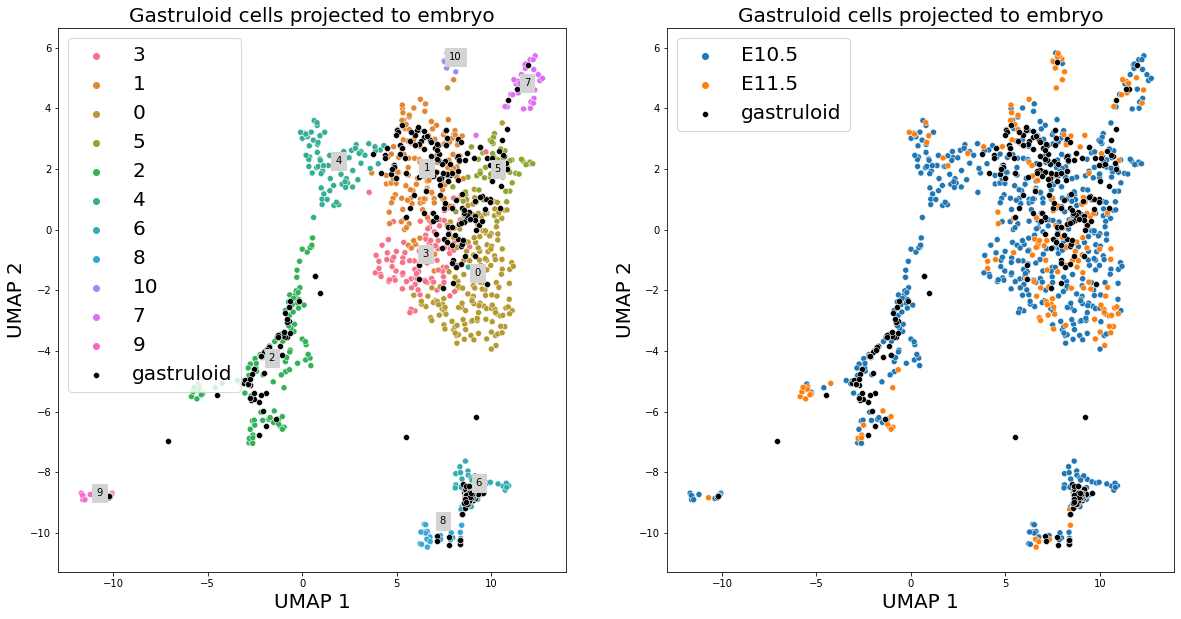

In [12]:
fig,ax = plt.subplots(1,2,figsize=[20,10])

# Clusters
adata_embryo.obs.loc[:,"Louvain Cluster"] = adata_embryo.obs.loc[:,"Louvain Cluster"].astype(str)
hue = adata_embryo.obs.loc[:,"Louvain Cluster"].astype(str)
sns.scatterplot(x=UMAP_embryo[:,0],y=UMAP_embryo[:,1],hue=hue,ax=ax[0])
sns.scatterplot(x=UMAP_gastruloid[:,0],y=UMAP_gastruloid[:,1],color="black",ax=ax[0],label="gastruloid")
for cluster in hue.unique():
    x = UMAP_embryo[adata_embryo.obs.loc[:,"Louvain Cluster"]==cluster,:][:,0].mean()
    y = UMAP_embryo[adata_embryo.obs.loc[:,"Louvain Cluster"]==cluster,:][:,1].mean()
    ax[0].text(x,y,cluster,backgroundcolor="lightgrey")
ax[0].legend(fontsize=20)
ax[0].set_xlabel("UMAP 1",fontsize=20)
ax[0].set_ylabel("UMAP 2",fontsize=20)
ax[0].set_title("Gastruloid cells projected to embryo",fontsize=20)

# Times
hue = adata_embryo.obs.loc[:,"Time"].astype(str)
sns.scatterplot(x=UMAP_embryo[:,0],y=UMAP_embryo[:,1],hue=hue,ax=ax[1])
sns.scatterplot(x=UMAP_gastruloid[:,0],y=UMAP_gastruloid[:,1],color="black",ax=ax[1],label="gastruloid")
ax[1].legend(fontsize=20)
ax[1].set_xlabel("UMAP 1",fontsize=20)
ax[1].set_ylabel("UMAP 2",fontsize=20)
ax[1].set_title("Gastruloid cells projected to embryo",fontsize=20)

fig.savefig("plots/global/embryo_umap_projection.png",bbox_inches="tight")

## Classify them in clusters

In [13]:
cluster_embryo = adata_embryo.obs.loc[:,["Louvain Cluster"]].astype(int).astype(str)

m = KNeighborsClassifier(3,metric="correlation")
m.fit(X_pca_embryo,cluster_embryo)

KNeighborsClassifier(metric='correlation', n_neighbors=3)

In [14]:
cluster_gastruloid = m.predict(X_pca_gastruloid)

In [15]:
adata_gastruloid.obs["clusters_from_embryo"] = cluster_gastruloid

Trying to set attribute `.obs` of view, copying.


In [16]:
matrix = adata_gastruloid.obs.groupby(["leiden_global","clusters_from_embryo"]).count().iloc[:,0].unstack().transpose()
matrix = matrix/matrix.sum(axis=0)

In [17]:
adata_gastruloid.obs["correlation"] = m.kneighbors(X_pca_gastruloid)[0].mean(axis=1)
matrix2 = adata_gastruloid.obs.groupby(["leiden_global","clusters_from_embryo"]).mean().loc[:,"correlation"].unstack().transpose()

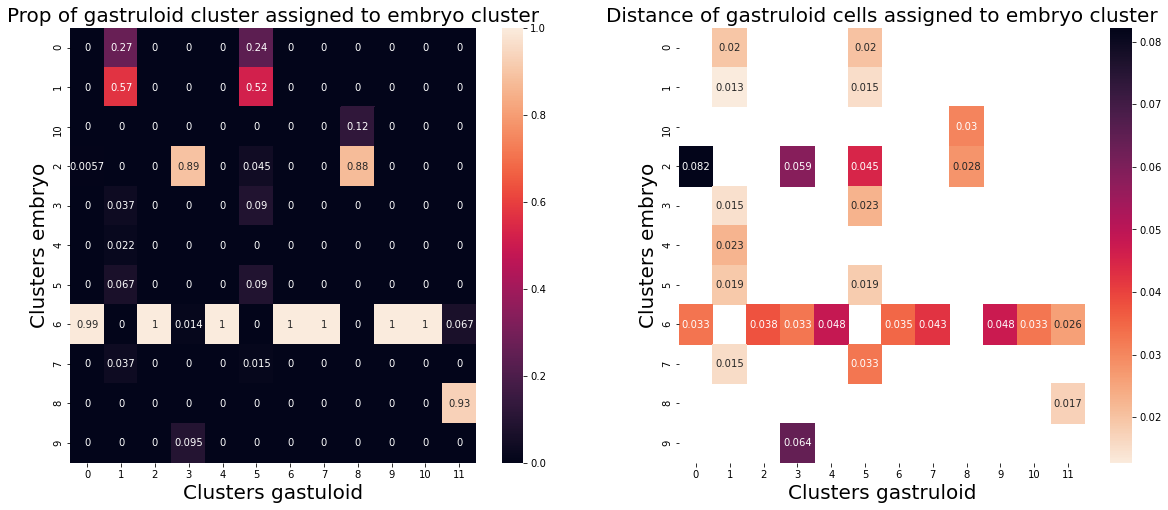

In [18]:
fig,ax = plt.subplots(1,2,figsize=[20,8])

sns.heatmap(matrix,annot=True,ax=ax[0])
ax[0].set_xlabel("Clusters gastuloid",fontsize=20)
ax[0].set_ylabel("Clusters embryo",fontsize=20)
ax[0].set_title("Prop of gastruloid cluster assigned to embryo cluster",fontsize=20)

sns.heatmap(matrix2,annot=True,ax=ax[1],cmap=sns.color_palette("rocket_r", as_cmap=True))
ax[1].set_xlabel("Clusters gastruloid",fontsize=20)
ax[1].set_ylabel("Clusters embryo",fontsize=20)
ax[1].set_title("Distance of gastruloid cells assigned to embryo cluster",fontsize=20)

fig.savefig("plots/global/embryo_clusters_overlap.png",bbox_inches="tight")

# Sorted

In [19]:
adata_embryo = scp.read("results/embryo/Embryo_corrected.h5ad")
adata_gastruloid = scp.read("results/subSamples/sorted/sorted.h5ad")

In [20]:
common_genes_embryo = [i in adata_gastruloid.var.index.values for i in adata_embryo.var.index.values]
common_genes_gastruloids = [i in adata_embryo.var.index.values for i in adata_gastruloid.var.index.values]

In [21]:
#Get to the common number of genes
adata_embryo = adata_embryo[:,common_genes_embryo]
adata_gastruloid = adata_gastruloid[:,common_genes_gastruloids]

## PCA embryo

In [22]:
scp.pp.highly_variable_genes(adata_embryo,flavor="seurat")
X = adata_embryo.X[:,adata_embryo.var.loc[:,"highly_variable"]]

Trying to set attribute `.uns` of view, copying.


In [23]:
m = TruncatedSVD(12)
m.fit(X)
X_pca_embryo = m.transform(X)

## Project gastruloids over PCA of the embryo

In [24]:
X = adata_gastruloid.X[:,adata_embryo.var.loc[:,"highly_variable"]]

In [25]:
X_pca_gastruloid = m.transform(X)

## Project over the UMAP

In [26]:
adata_embryo.obsm

AxisArrays with keys: X_umap_original

In [27]:
UMAP_embryo = adata_embryo.obsm["X_umap_original"]

m = KNeighborsRegressor(3,metric="correlation")
m.fit(X_pca_embryo,UMAP_embryo)

KNeighborsRegressor(metric='correlation', n_neighbors=3)

In [28]:
UMAP_gastruloid = m.predict(X_pca_gastruloid)

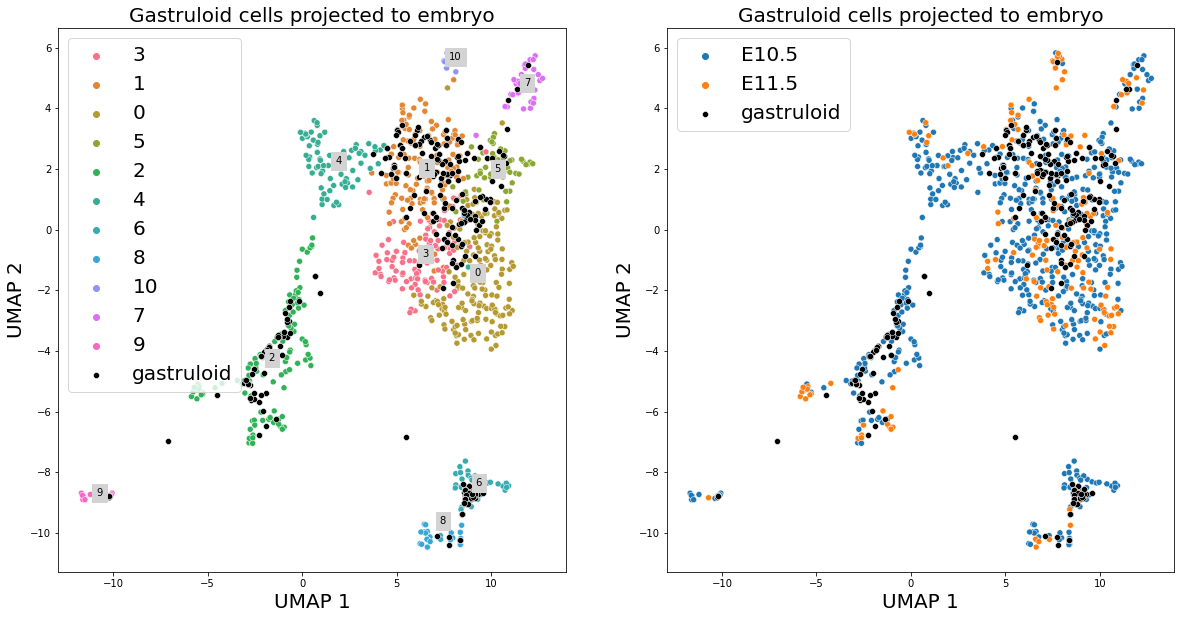

In [29]:
fig,ax = plt.subplots(1,2,figsize=[20,10])

# Clusters
adata_embryo.obs.loc[:,"Louvain Cluster"] = adata_embryo.obs.loc[:,"Louvain Cluster"].astype(str)
hue = adata_embryo.obs.loc[:,"Louvain Cluster"].astype(str)
sns.scatterplot(x=UMAP_embryo[:,0],y=UMAP_embryo[:,1],hue=hue,ax=ax[0])
sns.scatterplot(x=UMAP_gastruloid[:,0],y=UMAP_gastruloid[:,1],color="black",ax=ax[0],label="gastruloid")
for cluster in hue.unique():
    x = UMAP_embryo[adata_embryo.obs.loc[:,"Louvain Cluster"]==cluster,:][:,0].mean()
    y = UMAP_embryo[adata_embryo.obs.loc[:,"Louvain Cluster"]==cluster,:][:,1].mean()
    ax[0].text(x,y,cluster,backgroundcolor="lightgrey")
ax[0].legend(fontsize=20)
ax[0].set_xlabel("UMAP 1",fontsize=20)
ax[0].set_ylabel("UMAP 2",fontsize=20)
ax[0].set_title("Gastruloid cells projected to embryo",fontsize=20)

# Times
hue = adata_embryo.obs.loc[:,"Time"].astype(str)
sns.scatterplot(x=UMAP_embryo[:,0],y=UMAP_embryo[:,1],hue=hue,ax=ax[1])
sns.scatterplot(x=UMAP_gastruloid[:,0],y=UMAP_gastruloid[:,1],color="black",ax=ax[1],label="gastruloid")
ax[1].legend(fontsize=20)
ax[1].set_xlabel("UMAP 1",fontsize=20)
ax[1].set_ylabel("UMAP 2",fontsize=20)
ax[1].set_title("Gastruloid cells projected to embryo",fontsize=20)

fig.savefig("plots/sorted/embryo_umap_projection.png",bbox_inches="tight")

## Classify them in clusters

In [30]:
cluster_embryo = adata_embryo.obs.loc[:,["Louvain Cluster"]].astype(int).astype(str)

m = KNeighborsClassifier(3,metric="correlation")
m.fit(X_pca_embryo,cluster_embryo)

KNeighborsClassifier(metric='correlation', n_neighbors=3)

In [31]:
cluster_gastruloid = m.predict(X_pca_gastruloid)

In [32]:
adata_gastruloid.obs["clusters_from_embryo"] = cluster_gastruloid

Trying to set attribute `.obs` of view, copying.


In [33]:
matrix = adata_gastruloid.obs.groupby(["leiden_global","clusters_from_embryo"]).count().iloc[:,0].unstack().transpose()
matrix = matrix/matrix.sum(axis=0)

In [34]:
adata_gastruloid.obs["correlation"] = m.kneighbors(X_pca_gastruloid)[0].mean(axis=1)
matrix2 = adata_gastruloid.obs.groupby(["leiden_global","clusters_from_embryo"]).mean().loc[:,"correlation"].unstack().transpose()

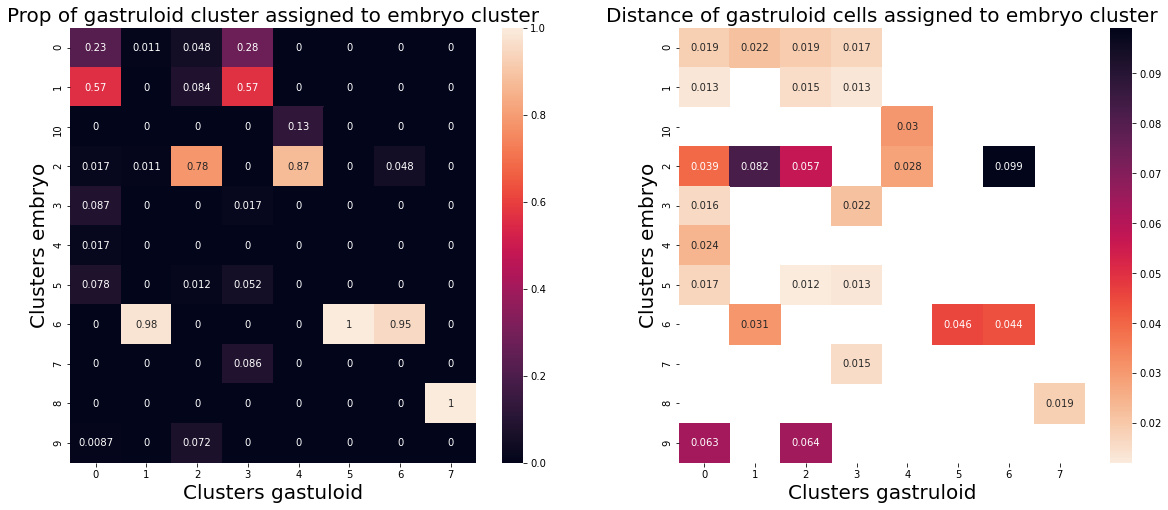

In [35]:
fig,ax = plt.subplots(1,2,figsize=[20,8])

sns.heatmap(matrix,annot=True,ax=ax[0])
ax[0].set_xlabel("Clusters gastuloid",fontsize=20)
ax[0].set_ylabel("Clusters embryo",fontsize=20)
ax[0].set_title("Prop of gastruloid cluster assigned to embryo cluster",fontsize=20)

sns.heatmap(matrix2,annot=True,ax=ax[1],cmap=sns.color_palette("rocket_r", as_cmap=True))
ax[1].set_xlabel("Clusters gastruloid",fontsize=20)
ax[1].set_ylabel("Clusters embryo",fontsize=20)
ax[1].set_title("Distance of gastruloid cells assigned to embryo cluster",fontsize=20)

fig.savefig("plots/sorted/embryo_clusters_overlap.png",bbox_inches="tight")